# DQN en vivo — LunarLander-v3

Entrena **300 episodios** y cada 50 pausa el entrenamiento para mostrarte el agente jugando en tiempo real.
Verás cómo mejora progresivamente desde estrellarse hasta intentar controlar el descenso.

In [1]:
import sys
sys.path.insert(0, 'src')

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import gymnasium as gym
import torch

from agents import DQNAgent

SEED = 2024
np.random.seed(SEED)
torch.manual_seed(SEED)
print('OK')

OK


In [2]:
# Entorno de entrenamiento (sin render, rápido)
env_train = gym.make('LunarLander-v3')
env_train.reset(seed=SEED)

# Entorno de visualización (rgb_array para capturar frames)
env_show = gym.make('LunarLander-v3', render_mode='rgb_array')

agent = DQNAgent(
    env_train,
    epsilon=1.0,
    alpha=0.001,
    discount_factor=0.99,
    decay=True,
    buffer_capacity=5000,
    batch_size=64,
    target_update_freq=100,
    hidden_size=32,
    num_hidden_layers=2,
    use_cpu=True
)
print('Agente listo')

Entrenando en: cpu
Agente listo


In [6]:
def demo_en_vivo(agent, env_show, ep_num, reward_history):
    """Ejecuta un episodio greedy mostrando cada frame en tiempo real."""
    saved_eps = agent.epsilon
    agent.epsilon = 0.0          # solo explotación

    obs, _ = env_show.reset(seed=SEED)
    done = False
    step = 0
    total_reward = 0.0

    while not done and step < 999:
        frame = env_show.render()       # captura el frame actual
        action = agent.get_action(obs)
        obs, reward, terminated, truncated, _ = env_show.step(action)
        done = terminated or truncated
        total_reward += reward
        step += 1

        # Actualiza la pantalla cada 4 pasos para mayor fluidez
        if step % 4 == 0 or done:
            clear_output(wait=True)
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

            ax1.imshow(frame)
            ax1.set_title(
                f'Episodio de entrenamiento {ep_num} '
                f'— paso {step} '
                f'— reward acum: {total_reward:.1f}',
                fontsize=11
            )
            ax1.axis('off')

            ax2.plot(reward_history, color='steelblue', linewidth=1.5)
            ax2.axhline(0,   color='gray',  linestyle='--', linewidth=0.8)
            ax2.axhline(200, color='green', linestyle='--', linewidth=0.8, label='objetivo (+200)')
            ax2.set_title('Recompensa media acumulada', fontsize=11)
            ax2.set_xlabel('Episodio')
            ax2.legend(loc='lower right', fontsize=9)
            ax2.grid(True, alpha=0.3)

            plt.tight_layout()
            plt.show()

    agent.epsilon = saved_eps
    return total_reward

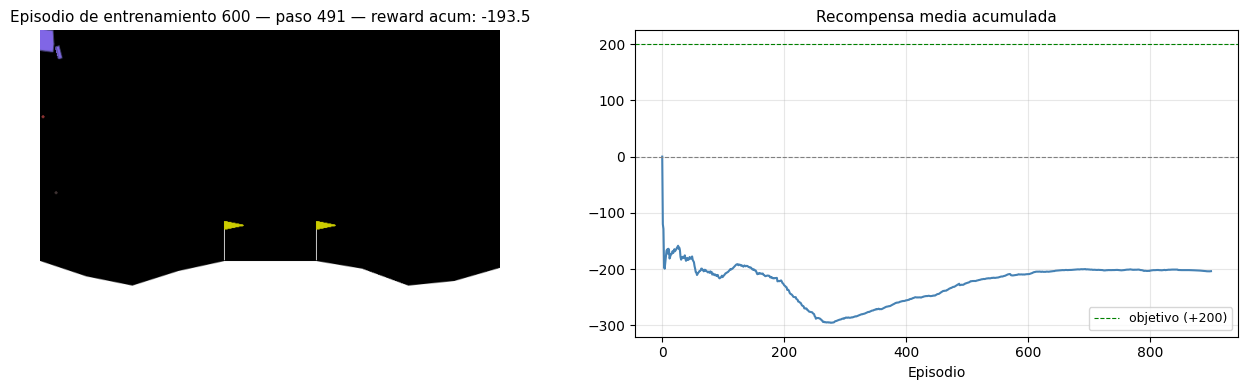

[EP 600]  reward_media= -203.88  epsilon=0.011  demo_reward=-193.5
Entrenamiento terminado


In [7]:
N_EPISODES  = 600   # episodios de entrenamiento
DEMO_EVERY  = 50    # mostrar demo cada N episodios

raw_rewards = []    # reward real de cada episodio (sin suavizar)

for ep in range(N_EPISODES):

    # ── Entrenamiento de un episodio ──────────────────────────
    obs, _ = env_train.reset()
    done = False
    ep_reward = 0.0
    ep_length = 0

    while not done:
        action = agent.get_action(obs)
        next_obs, reward, terminated, truncated, info = env_train.step(action)
        agent.update(obs, action, reward, next_obs, terminated, truncated, info)
        obs = next_obs
        done = terminated or truncated
        ep_reward += reward
        ep_length += 1

    if agent.decay:
        agent.epsilon = max(0.01, agent.epsilon * 0.995)
    agent.update_stats(ep_reward, ep_length)
    raw_rewards.append(ep_reward)

    # ── Demo en vivo: ep 1, luego cada DEMO_EVERY ─────────────
    if ep == 0 or (ep + 1) % DEMO_EVERY == 0:
        demo_reward = demo_en_vivo(agent, env_show, ep + 1, agent._list_stats)
        print(f'[EP {ep+1:>3d}]  '
              f'reward_media={agent._list_stats[-1]:>8.2f}  '
              f'epsilon={agent.epsilon:.3f}  '
              f'demo_reward={demo_reward:.1f}')

env_train.close()
env_show.close()
print('Entrenamiento terminado')

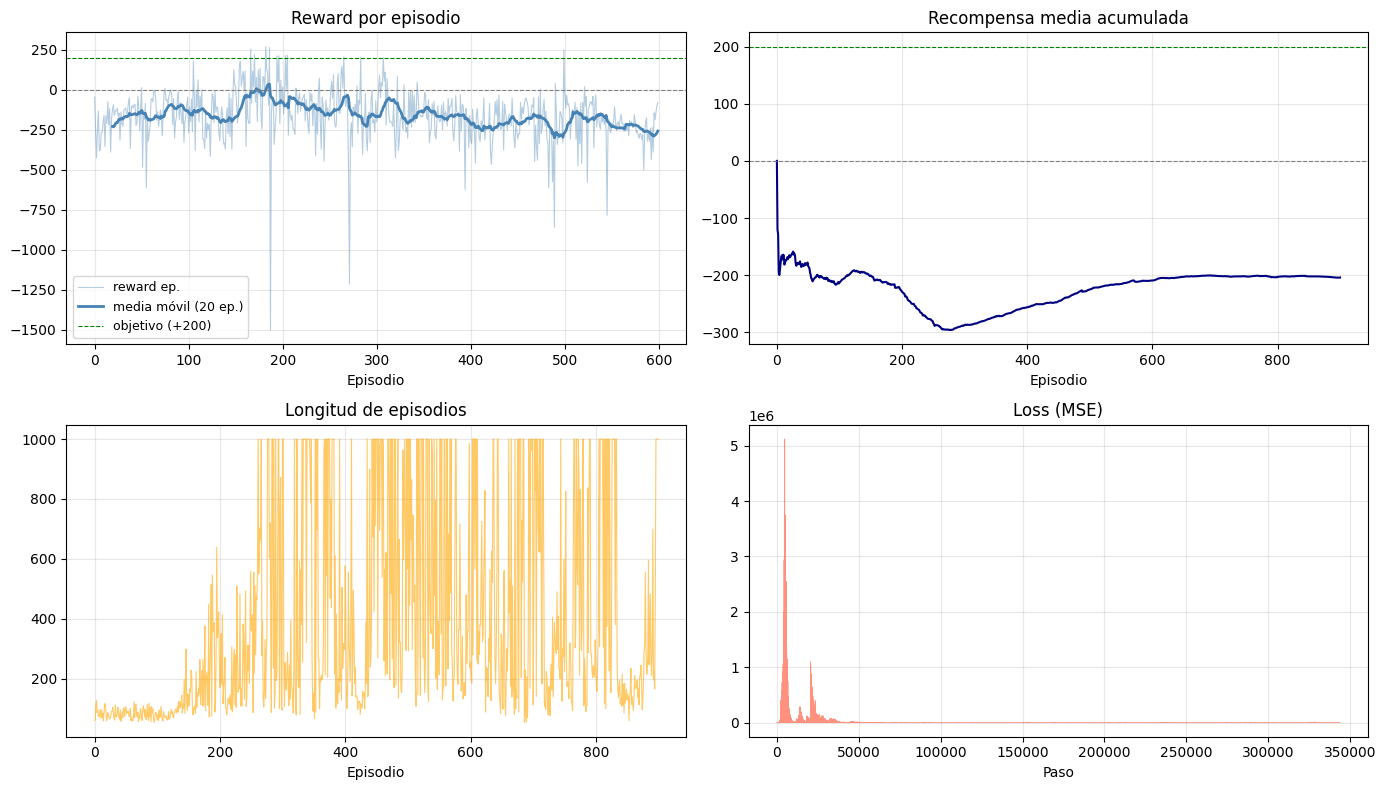

Reward media final (media acum.) : -203.88
Reward media final (media móvil) : -258.21
Longitud media (ult 50 ep.)      : 292.4 pasos
Epsilon final                    : 0.0110
Pasos totales                    : 343924


In [8]:
list_stats, list_lengths, list_losses = agent.stats()

# Suavizado de rewards brutas (media móvil de 20 episodios)
window = 20
smooth = np.convolve(raw_rewards, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# ── Reward por episodio (bruta + suavizada) ───────────────────
axes[0, 0].plot(raw_rewards, color='steelblue', linewidth=0.8, alpha=0.4, label='reward ep.')
axes[0, 0].plot(range(window-1, len(raw_rewards)), smooth, color='steelblue', linewidth=2, label=f'media móvil ({window} ep.)')
axes[0, 0].axhline(0,   color='gray',  linestyle='--', linewidth=0.8)
axes[0, 0].axhline(200, color='green', linestyle='--', linewidth=0.8, label='objetivo (+200)')
axes[0, 0].set_title('Reward por episodio')
axes[0, 0].set_xlabel('Episodio')
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(True, alpha=0.3)

# ── Recompensa media acumulada ────────────────────────────────
axes[0, 1].plot(list_stats, color='navy', linewidth=1.5)
axes[0, 1].axhline(0,   color='gray',  linestyle='--', linewidth=0.8)
axes[0, 1].axhline(200, color='green', linestyle='--', linewidth=0.8)
axes[0, 1].set_title('Recompensa media acumulada')
axes[0, 1].set_xlabel('Episodio')
axes[0, 1].grid(True, alpha=0.3)

# ── Longitud de episodios ─────────────────────────────────────
axes[1, 0].plot(list_lengths, color='orange', linewidth=0.8, alpha=0.6)
axes[1, 0].set_title('Longitud de episodios')
axes[1, 0].set_xlabel('Episodio')
axes[1, 0].grid(True, alpha=0.3)

# ── Loss ──────────────────────────────────────────────────────
axes[1, 1].plot(list_losses, color='tomato', linewidth=0.6, alpha=0.7)
axes[1, 1].set_title('Loss (MSE)')
axes[1, 1].set_xlabel('Paso')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Reward media final (media acum.) : {list_stats[-1]:.2f}')
print(f'Reward media final (media móvil) : {smooth[-1]:.2f}')
print(f'Longitud media (ult 50 ep.)      : {np.mean(list_lengths[-50:]):.1f} pasos')
print(f'Epsilon final                    : {agent.epsilon:.4f}')
print(f'Pasos totales                    : {agent._step_count}')